# Boundary Generation — Semifreddo + Ledidi (single example)

Optimises the central bin (index 256 in the 512-bin map, index 320 counting the
64-bin cropping offset) of a flat genomic region to produce a strong boundary.

**Key difference from full-sequence optimisation:** only the 11-bin padded sequence
slice around the edited bin is passed through the convolutional tower on each step;
all other activations are served from the pre-cached tower output.

```
center bin (in map) : 256
center bin (in 640) : 256 + 64 (cropping) = 320
sequence window     : bin 315–325 → (320-5)*2048 to (320+6)*2048 = 11 bins = 22 528 bp
bins replaced       : 318–322 (central 5)
```


## 1. Imports

In [1]:
import os
import sys

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

sys.path.append(os.path.abspath("/home1/smaruj/pytorch_akita/"))
sys.path.insert(0, "/home1/smaruj/ledidi/ledidi/")
sys.path.insert(0, os.path.abspath("/home1/smaruj/ledidi_akita/"))

from akita.model import SeqNN
from ledidi import Ledidi
from semifreddo.semifreddo import SemifreddoLedidiWrapper
from utils.data_utils import from_upper_triu
from utils.losses_utils import LocalL1Loss

## 2. Parameters

In [2]:
# ── Sequence to optimise ─────────────────────────────────────────────────
FOLD  = 0
CHROM = "chr3"
START = 38438912
END   = 39749632
STEM  = f"{CHROM}_{START}_{END}"

SEQ_BASE_DIR   = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/analysis/flat_regions"
TARGET_DIR = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/boundaries"
MASK_DIR     = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/feature_masks"
MODEL_PATH = ("/home1/smaruj/pytorch_akita/models/finetuned/mouse/Hsieh2019_mESC/checkpoints/"
              "Akita_v2_mouse_Hsieh2019_mESC_model0_finetuned.pth")

SEQ_PATH    = f"{SEQ_BASE_DIR}/mouse_sequences/fold{FOLD}/{STEM}_X.pt"
TOWER_PATH  = f"{SEQ_BASE_DIR}/mouse_tower_outputs/fold{FOLD}/{STEM}_tower_out.pt"
TARGET_PATH = f"{TARGET_DIR}/targets/boundary_neg0p5/fold{FOLD}/{STEM}_target.pt"
MASK_PATH = f"{MASK_DIR}/boundary_mask.pt"

# ── Semifreddo bin coordinates ────────────────────────────────────────────
# Central bin in the 512-bin contact map
CENTER_BIN_MAP = 256
# Same bin in the 640-bin tower output (add the 64-bin Akita cropping offset)
CENTER_BIN_640 = CENTER_BIN_MAP + 64   # = 320
CONTEXT_BINS   = 5   # ±5 bins → 11-bin window → Pearson R = 1.0 vs full model
BIN_SIZE       = 2048  # bp per bin

# ── Optimisation hyperparameters ─────────────────────────────────────────
L                  = 7.0   # input-loss regularisation weight
MAX_ITER           = 2000
EARLY_STOPPING     = 2000

# ── Visualisation ────────────────────────────────────────────────────────
VMIN, VMAX = -0.6, 0.6
CMAP       = 'RdBu_r'

## 3. Load Model

In [3]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = SeqNN()
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.to(device).eval()
print("Model loaded")

Device: cuda:0
Model loaded


## 4. Load Pre-generated Files

In [4]:
X      = torch.load(SEQ_PATH,    weights_only=True).to(device)               # (1, 4, L)
tower  = torch.load(TOWER_PATH,  weights_only=True).to(device)               # (1, 128, 640)
target = torch.load(TARGET_PATH, weights_only=True).to(device)               # (1, 1, N_triu)

print(f"X shape      : {X.shape}")
print(f"Tower shape  : {tower.shape}")
print(f"Target shape : {target.shape}")

X shape      : torch.Size([1, 4, 1310720])
Tower shape  : torch.Size([1, 128, 640])
Target shape : torch.Size([1, 1, 130305])


## 5. Build SemifreddoLedidiWrapper

The wrapper extracts the 11-bin padded sequence slice from `X` on every Ledidi step
and runs only that slice through the convolutional tower, splicing the result back
into the cached `tower` activations.

In [5]:
sf_wrapper = SemifreddoLedidiWrapper(
    model                   = model,
    precomputed_full_output = tower,
    full_X                  = X,
    edited_bin              = CENTER_BIN_MAP,   # 256, NOT 320
    context_bins            = CONTEXT_BINS,
    cropping_applied        = 64,
)

print(f"Sequence slice : bp {sf_wrapper.seq_slice_start:,} – {sf_wrapper.seq_slice_end:,}")
print(f"Center bin bp  : {sf_wrapper.center_bp_start:,} – {sf_wrapper.center_bp_end:,}")

# Sanity check — pass only the central bin
X_center = X[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end]  # (1, 4, 2048)

with torch.no_grad():
    y_full = model(X)
    y_sf   = sf_wrapper(X_center)

r, _ = pearsonr(y_full.cpu().flatten().numpy(), y_sf.cpu().flatten().numpy())
print(f"\nSanity check — Pearson R (full vs Semifreddo): {r:.6f}  (expect 1.0)")

Sequence slice : bp 645,120 – 667,648
Center bin bp  : 655,360 – 657,408

Sanity check — Pearson R (full vs Semifreddo): 1.000000  (expect 1.0)


/home1/smaruj/miniconda3/envs/pytorch_hic/lib/python3.10/site-packages/torch/nn/modules/conv.py:306: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:84.)
  return F.conv1d(input, weight, bias, self.stride,


## 6. Run Ledidi Optimisation

Ledidi receives `SemifreddoLedidiWrapper` as its model.
On every step it calls `sf_wrapper(X_hat)`, which:
1. Slices `X_hat[:, :, seq_slice_start:seq_slice_end]` — the 11-bin window
2. Passes only that 22 528 bp slice through `conv_block_1 → conv_tower`
3. Splices the 5 central recomputed bins into the cached tower activations
4. Runs the full trunk to produce the contact map prediction

In [6]:
# Load mask
boundary_mask = torch.load(MASK_PATH, weights_only=True).to(device)

local_output_loss = LocalL1Loss(boundary_mask, reduction='sum').to(device)

In [7]:
ledidi_optimizer = Ledidi(
    sf_wrapper,
    shape              = X_center.shape[1:],          # (4, 2048)
    input_loss         = torch.nn.L1Loss(reduction='sum'),
    output_loss        = local_output_loss,
    batch_size         = 1,
    l                  = L,
    max_iter           = MAX_ITER,
    early_stopping_iter = EARLY_STOPPING,
    return_history     = True,
    verbose            = True,
).cuda()

generated_seq, history = ledidi_optimizer.fit_transform(X_center, target)

iter=I	input_loss=0.0	output_loss=2.582e+04	total_loss=2.582e+04	time=0.0
iter=100	input_loss=198.0	output_loss=1.749e+04	total_loss=1.888e+04	time=7.411
iter=200	input_loss=316.0	output_loss=1.238e+04	total_loss=1.459e+04	time=7.323
iter=300	input_loss=250.0	output_loss=1.19e+04	total_loss=1.365e+04	time=7.322
iter=400	input_loss=222.0	output_loss=1.172e+04	total_loss=1.327e+04	time=7.323
iter=500	input_loss=204.0	output_loss=1.169e+04	total_loss=1.312e+04	time=7.324
iter=600	input_loss=189.0	output_loss=1.172e+04	total_loss=1.304e+04	time=7.324
iter=700	input_loss=205.0	output_loss=1.166e+04	total_loss=1.31e+04	time=7.326
iter=800	input_loss=190.0	output_loss=1.164e+04	total_loss=1.297e+04	time=7.325
iter=900	input_loss=180.0	output_loss=1.165e+04	total_loss=1.291e+04	time=7.339
iter=1000	input_loss=192.0	output_loss=1.165e+04	total_loss=1.3e+04	time=7.301
iter=1100	input_loss=198.0	output_loss=1.168e+04	total_loss=1.306e+04	time=7.298
iter=1200	input_loss=198.0	output_loss=1.165e+04

In [8]:
# Then reconstruct full sequence afterward
full_generated_seq = X.clone()
full_generated_seq[:, :, sf_wrapper.center_bp_start:sf_wrapper.center_bp_end] = generated_seq

## 7. Loss Curves

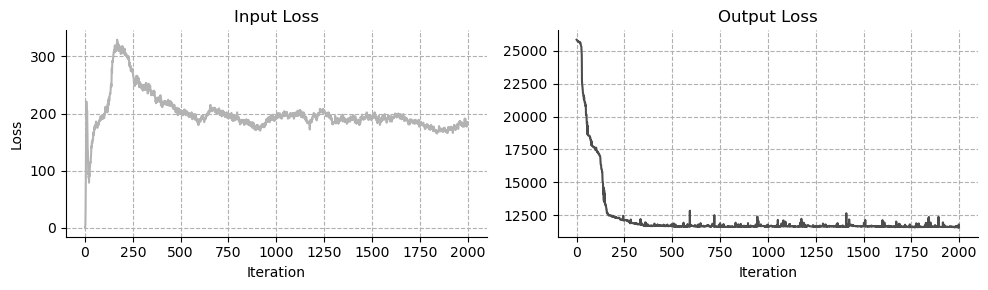

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))

axes[0].plot(history['input_loss'],  c='0.7')
axes[0].set_title('Input Loss')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss')
axes[0].grid(True, linestyle='--')

axes[1].plot(history['output_loss'], c='0.3')
axes[1].set_title('Output Loss')
axes[1].set_xlabel('Iteration')
axes[1].grid(True, linestyle='--')

sns.despine()
plt.tight_layout()
plt.show()

## 8. Number of Edits

In [10]:
n_edits = (torch.argmax(full_generated_seq, dim=1) != torch.argmax(X, dim=1)).sum().item()
print(f"Number of edited nucleotides: {n_edits:,}")

Number of edited nucleotides: 166


## 9. Predicted Contact Maps

In [11]:
model.eval()
with torch.no_grad():
    pred_optimised = model(full_generated_seq)
    pred_initial   = model(X)

r_opt, _ = pearsonr(
    pred_optimised.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
r_init, _ = pearsonr(
    pred_initial.cpu().flatten().numpy(),
    target.cpu().flatten().numpy(),
)
print(f"Pearson R (optimised vs target) : {r_opt:.4f}")
print(f"Pearson R (initial   vs target) : {r_init:.4f}")

Pearson R (optimised vs target) : 0.7550
Pearson R (initial   vs target) : 0.4403


## 10. Contact Map Visualisation

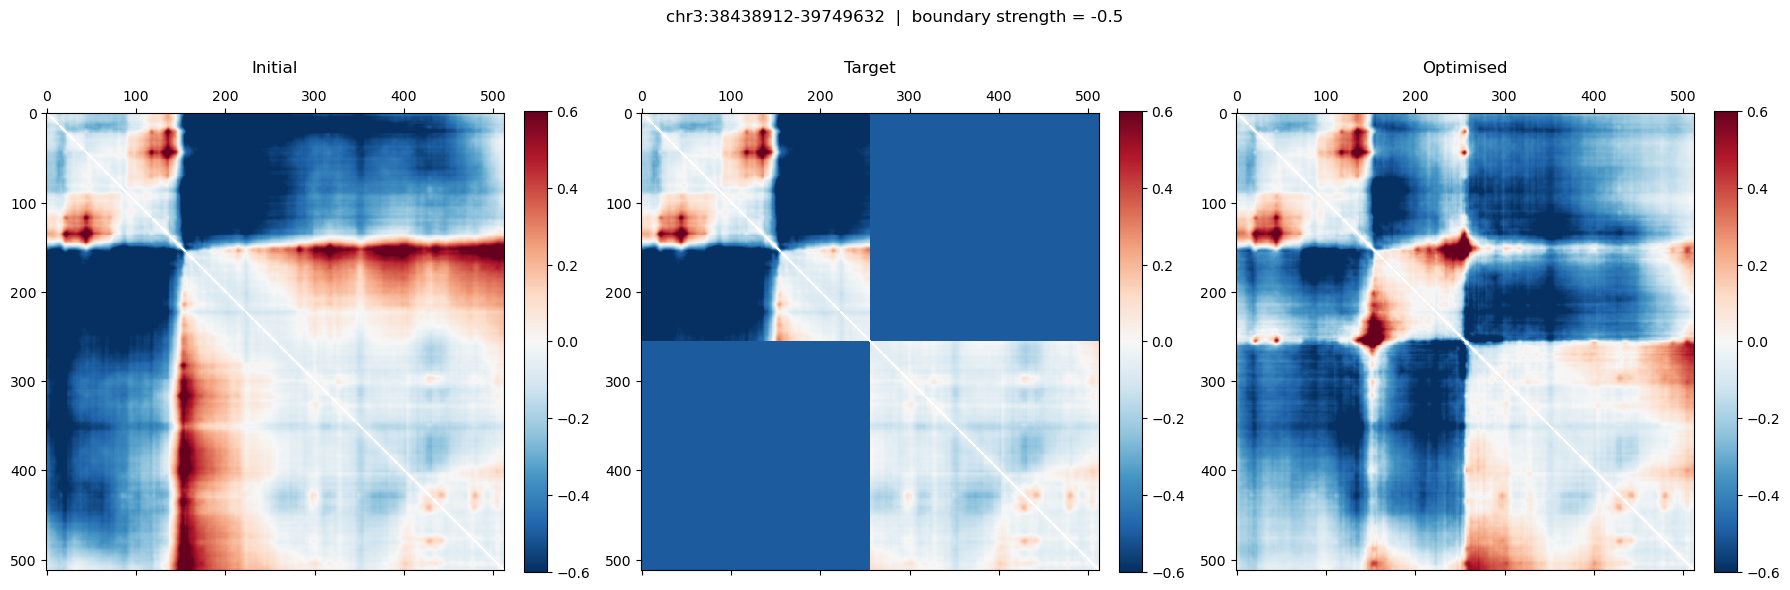

In [12]:
mat_initial   = from_upper_triu(pred_initial[0, 0, :],   matrix_len=512, num_diags=2)
mat_optimised = from_upper_triu(pred_optimised[0, 0, :],  matrix_len=512, num_diags=2)
mat_target    = from_upper_triu(target[0, 0, :],          matrix_len=512, num_diags=2)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
titles = ['Initial', 'Target', 'Optimised']
matrices = [mat_initial, mat_target, mat_optimised]

for ax, mat, title in zip(axes, matrices, titles):
    im = ax.matshow(mat.astype(np.float32), cmap=CMAP, vmin=VMIN, vmax=VMAX)
    ax.set_title(title, pad=12)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(f"{CHROM}:{START}-{END}  |  boundary strength = -0.5", y=1.02)
plt.tight_layout()
# plt.savefig(f"./../plots/boundary_sf_{STEM}.svg", format='svg', bbox_inches='tight')
plt.show()